In [1]:
MODEL_MAPPING = {
    'M0': '1769979283', 
    'M1': '1769717823',
    'M2': '1769712572',
    'M3': '1769715063',
    'M4': '1769376434',
}

In [4]:
indices = {split: None for split in ["train", "val", "test"]}

for short_model_name, iconq_model_id in MODEL_MAPPING.items():

    if len(iconq_model_id) == 0:
        continue

    model_dir = os.path.join(
        pu.get_data_path(),
        "iconq_models",
        iconq_model_id,
    )

    for split in ["train", "val", "test"]:
        with open(
            os.path.join(model_dir, f"{split}_indices.pkl"),
            "rb",
        ) as f:
            local_indices = pickle.load(f)

        if indices[split] is None:
            indices[split] = local_indices
        else:
            assert indices[split] == local_indices
        

In [3]:
import argparse
import os
import pickle
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Subset
from tqdm.auto import tqdm

import autoslo.utils.paths as pu
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.models.iconq_model import IconqModel
from autoslo.models.model_prediction import ModelPrediction
from autoslo.nn.concurrent_query_dataset import ConcurrentQueryDataset
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace
from autoslo.utils.colors import Palette

In [5]:
results = {
    short_model_name: {
        split: {
            "p50": 10.0,
            "p90": 10.0,
            "p95": 10.0,
        }
        for split in ["train", "val", "test"]
    }
    for short_model_name in MODEL_MAPPING.keys()
}
results

{'M0': {'train': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'val': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'test': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0}},
 'M1': {'train': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'val': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'test': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0}},
 'M2': {'train': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'val': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'test': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0}},
 'M3': {'train': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'val': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'test': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0}},
 'M4': {'train': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'val': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0},
  'test': {'p50': 10.0, 'p90': 10.0, 'p95': 10.0}}}

In [52]:
true_y = {split: {} for split in ["train", "val", "test"]}
pred_y = {
    short_model_name: {split: {} for split in ["train", "val", "test"]}
    for short_model_name in MODEL_MAPPING.keys()
}

In [ ]:
def q_error(true, pred, true_is_lower_bound):
    base_q_error = np.maximum(true / pred, pred / true)
    if true_is_lower_bound and pred > true:
        return 1
    return base_q_error

In [ ]:
for short_model_name, iconq_model_id in MODEL_MAPPING.items():

    if len(iconq_model_id) == 0:
        continue

    model = IconqModel.load(
        model_id=iconq_model_id,
    )

    trained_on_log_runtime = model.trained_on_log_runtime

    model_dir = os.path.join(
        pu.get_data_path(),
        "iconq_models",
        iconq_model_id,
    )

    overall_dataset_path = os.path.join(model_dir, "dataset.pkl")
    dataset = ConcurrentQueryDataset.load_from(overall_dataset_path)
    split_datasets = {}
    for split in ["train", "val", "test"]:
        with open(
            os.path.join(model_dir, f"{split}_indices.pkl"),
            "rb",
        ) as f:
            indices = pickle.load(f)
        split_dataset = Subset(dataset=dataset, indices=indices)

        if len(true_y[split]) == 0:
            for i in range(len(split_dataset)):
                x, _, y, query_id, _, _, y_is_lower_bound = split_dataset[i]
                true_y[split][query_id.split('#')[0]] = (
                    y.item() if not trained_on_log_runtime else np.exp(y.item()), 
                    y_is_lower_bound,
                    len(x)
                )

        if len(pred_y[short_model_name][split]) == 0:
            pred_y_local = model.predict_from_dataset(
                dataset=split_dataset,
            )
            pred_y[short_model_name][split] = {
                query_id.split('#')[0]: pred.overall_mean_s() 
                for query_id, pred in pred_y_local.items()
            }
        
        q_errors = []
        for query_id, pred in pred_y[short_model_name][split].items():
            true, true_is_lower_bound, num_concurrent_queries = true_y[split][query_id]
            
            q_err = q_error(
                true=true,
                pred=pred,
                true_is_lower_bound=true_is_lower_bound,
            )
            q_errors.append(q_err)


        results[short_model_name][split]["p50"] = np.percentile(q_errors, 50)
        results[short_model_name][split]["p90"] = np.percentile(q_errors, 90)
        results[short_model_name][split]["p95"] = np.percentile(q_errors, 95)





Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1769979283/model_1769981089.pth
Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1769717823/model_1769720375.pth
Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1769712572/model_1769714434.pth
Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1769715063/model_1769716982.pth
Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1769376434/model_1769377368.pth


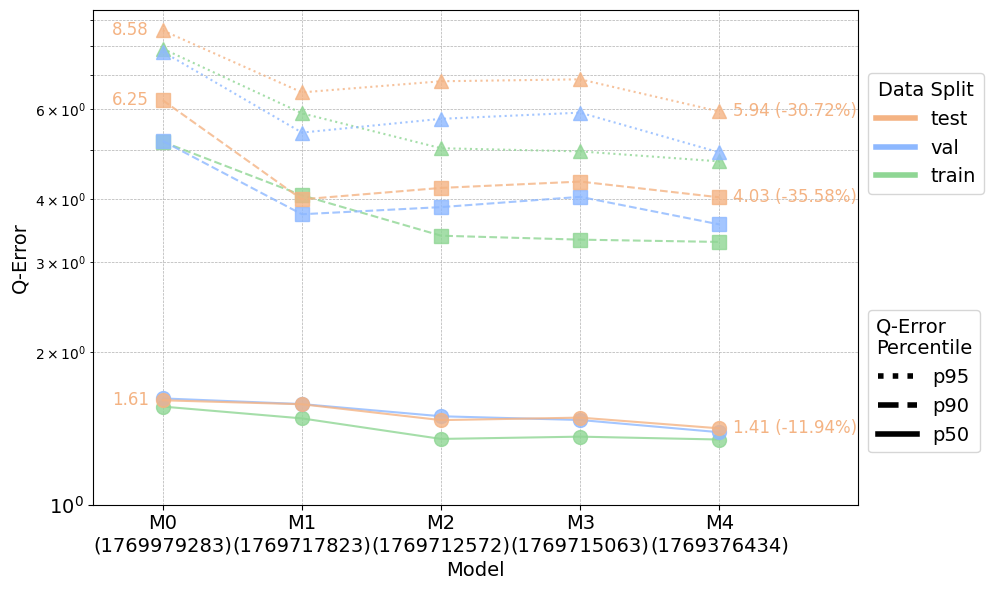

In [55]:
# Plot a line chart where y axis is the Q-error, x axis are the models, 
# and there is a line for each combination of split and percentile. Make
# The lines from the same split use the same color, and the lines from the
# same percentile use the same line style (solid, dashed, dotted).
import matplotlib.pyplot as plt


def plot_qerror_comparison(results, model_mapping, filename, initial, final):

    fig, ax = plt.subplots(figsize=(10, 6))
    fontsize=14
    markersize=10
    alpha = 0.8


    colors = {
        "train": Palette.light_green,
        "val": Palette.light_blue,
        "test": Palette.light_orange,
    }

    for split, color in colors.items():
        p50_values = [
        results[short_model_name][split]["p50"]
            for short_model_name in model_mapping.keys()
        ]
        p90_values = [
            results[short_model_name][split]["p90"]
            for short_model_name in model_mapping.keys()
        ]
        p95_values = [
            results[short_model_name][split]["p95"]
            for short_model_name in model_mapping.keys()
        ]

        ax.plot(
            list(model_mapping.keys()),
            p50_values,
            label=f"{split} p50",
            color=color,
            linestyle="solid",
            marker="o",
            markersize=markersize,
            alpha = alpha
        )
        ax.plot(
            list(model_mapping.keys()),
            p90_values,
            label=f"{split} p90",
            color=color,
            linestyle="dashed",
            marker="s",
            markersize=markersize,
            alpha = alpha
        )
        ax.plot(
            list(model_mapping.keys()),
            p95_values,
            label=f"{split} p95",
            color=color,
            linestyle="dotted",
            marker="^",
            markersize=markersize,
            alpha = alpha
        )


    # Add a text label to the left of each point for M0, and to the right of each point for M4.
    for split, color in colors.items():
        if split != "test":
            continue
        for percentile, linestyle in [("p50", "solid"), ("p90", "dashed"), ("p95", "dotted")]:
            initial_y_value = results[initial][split][percentile]
            ax.text(
                x=-0.1,
                y=initial_y_value,
                s=f"{initial_y_value:.2f}",
                color=color,
                fontsize=fontsize - 2,
                verticalalignment='center',
                horizontalalignment='right',
            )

            final_y_value = results[final][split][percentile]
            ax.text(
                x=len(model_mapping)-0.9,
                y=final_y_value,
                s=f"{final_y_value:.2f} ({-100*(initial_y_value -final_y_value) / initial_y_value:+.2f}%)",
                color=color,
                fontsize=fontsize - 2,
                verticalalignment='center',
                horizontalalignment='left',
            )



    ax.set_xlabel("Model", fontsize=fontsize)
    ax.set_ylabel("Q-Error", fontsize=fontsize)
    ax.set_yscale("log")

    # Create two 3-element legends to the right of the plot, one explaining
    # the colors (splits) and one explaining the line styles (percentiles).
    # Color legend
    color_legend = ax.legend(
        [plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()][::-1],
        list(colors.keys())[::-1],
        title="Data Split",
        loc="center left",
        fontsize=fontsize,
        title_fontsize=fontsize,
        bbox_to_anchor=(1.0, 0.75),
    )

    # Line style legend
    line_styles = {
        "p50": "solid",
        "p90": "dashed",
        "p95": "dotted",
    }
    line_legend = ax.legend(
        [
            plt.Line2D([0], [0], color="black", lw=4, linestyle=style)
            for style in line_styles.values()
        ][::-1],
        list(line_styles.keys())[::-1],
        title="Q-Error\nPercentile",
        loc="center left",
        bbox_to_anchor=(1.0, 0.25),
        fontsize=fontsize,
        title_fontsize=fontsize,
    )
    ax.add_artist(color_legend)



    # Add grid
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


    ax.set_ylim(bottom=1)
    ax.set_xlim(-0.5, len(model_mapping))

    ax.tick_params(axis='both', which='major', labelsize=fontsize)


    # Under each x tick, add the model timestamp from model_mapping. Make the
    # font size half of the main fontsize, but only for the timestamp line. Print
    # the actual model name on the first line, in fontsize fontsize.
    ax.set_xticks(
        range(len(model_mapping)),
        [
            f"{model_name}\n({model_mapping[model_name]})"
            for model_name in model_mapping.keys()
        ],
        fontsize=fontsize
    )

    # Adjust font size of ticks

    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches='tight')

plot_qerror_comparison(
    results=results,
    model_mapping=MODEL_MAPPING,
    filename="model_comparison_qerror_plot.svg",
    initial="M0",
    final="M4",
)


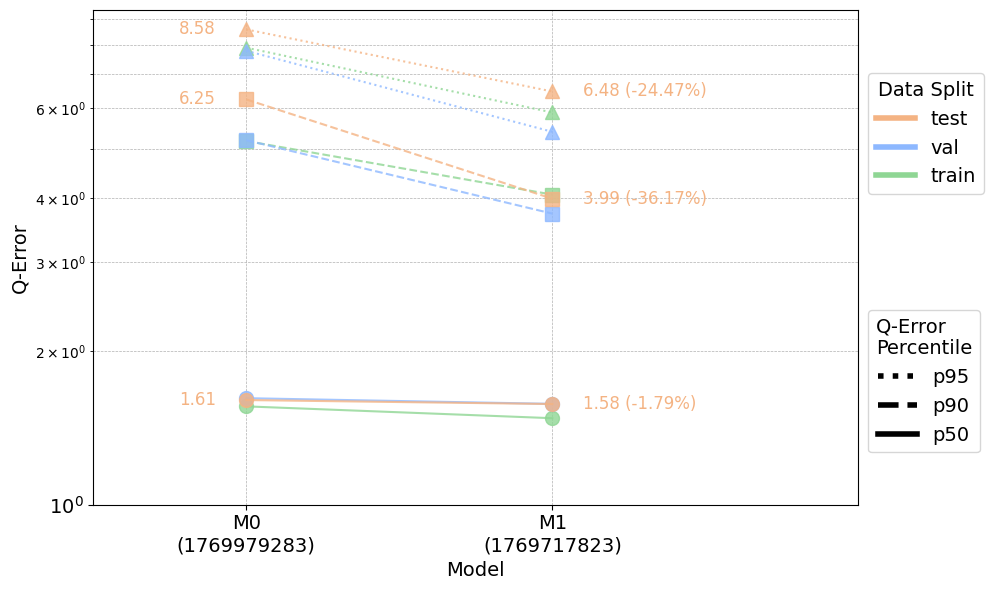

In [48]:
plot_qerror_comparison(
    results=results,
    # Only have M0 and M1
    model_mapping={
        'M0': MODEL_MAPPING['M0'],
        'M1': MODEL_MAPPING['M1'],
    },
    filename="model_comparison_qerror_plot_m0_m1.svg",
    initial="M0",
    final="M1",
)

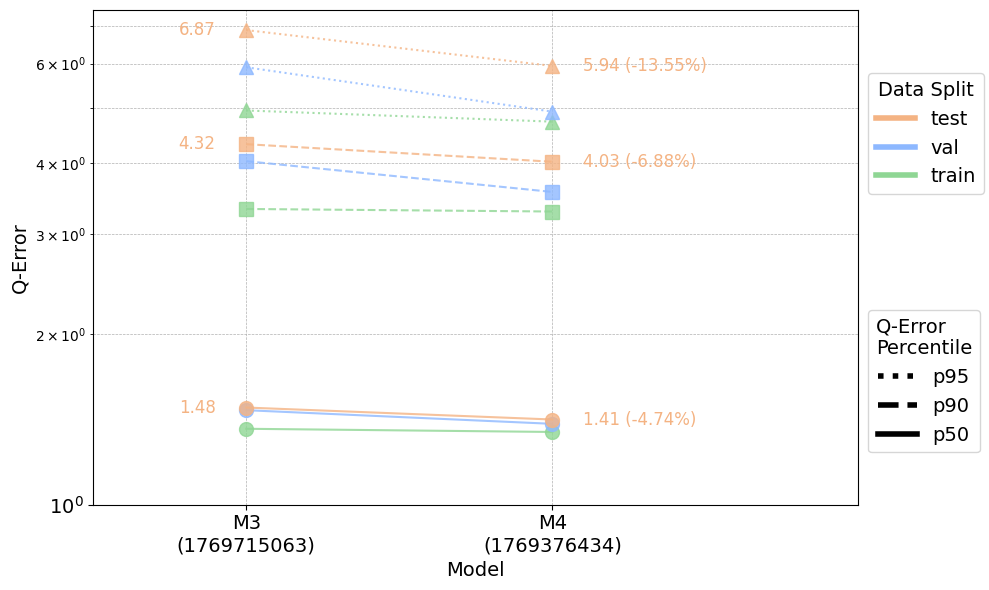

In [49]:
plot_qerror_comparison(
    results=results,
    model_mapping={
        'M3': MODEL_MAPPING['M3'],
        'M4': MODEL_MAPPING['M4'],
    },
    filename="model_comparison_qerror_plot_m3_m4.svg",
    initial="M3",
    final="M4",
)

In [50]:
# Create a version of results that only contains queries that are lower bounds, and one that contains queries that are not lower bounds.
lower_bound_results = {
    short_model_name: {
        split: {
            "p50": 10.0,
            "p90": 10.0,
            "p95": 10.0,
        }
        for split in ["train", "val", "test"]
    }
    for short_model_name in MODEL_MAPPING.keys()
}   
non_lower_bound_results = {
    short_model_name: {
        split: {
            "p50": 10.0,
            "p90": 10.0,
            "p95": 10.0,
        }
        for split in ["train", "val", "test"]
    }
    for short_model_name in MODEL_MAPPING.keys()
}

for short_model_name, iconq_model_id in MODEL_MAPPING.items():

    if len(iconq_model_id) == 0:
        continue

    q_errors_lower_bound = {split: [] for split in ["train", "val", "test"]}
    q_errors_non_lower_bound = {split: [] for split in ["train", "val", "test"]}

    for split in ["train", "val", "test"]:
        for query_id, pred in pred_y[short_model_name][split].items():
            true, true_is_lower_bound = true_y[split][query_id]
            
            q_err = q_error(
                true=true,
                pred=pred,
                true_is_lower_bound=true_is_lower_bound,
            )
            if true_is_lower_bound:
                q_errors_lower_bound[split].append(q_err)
            else:
                q_errors_non_lower_bound[split].append(q_err)

        lower_bound_results[short_model_name][split]["p50"] = np.percentile(q_errors_lower_bound[split], 50)
        lower_bound_results[short_model_name][split]["p90"] = np.percentile(q_errors_lower_bound[split], 90)
        lower_bound_results[short_model_name][split]["p95"] = np.percentile(q_errors_lower_bound[split], 95)

        non_lower_bound_results[short_model_name][split]["p50"] = np.percentile(q_errors_non_lower_bound[split], 50)
        non_lower_bound_results[short_model_name][split]["p90"] = np.percentile(q_errors_non_lower_bound[split], 90)
        non_lower_bound_results[short_model_name][split]["p95"] = np.percentile(q_errors_non_lower_bound[split], 95)



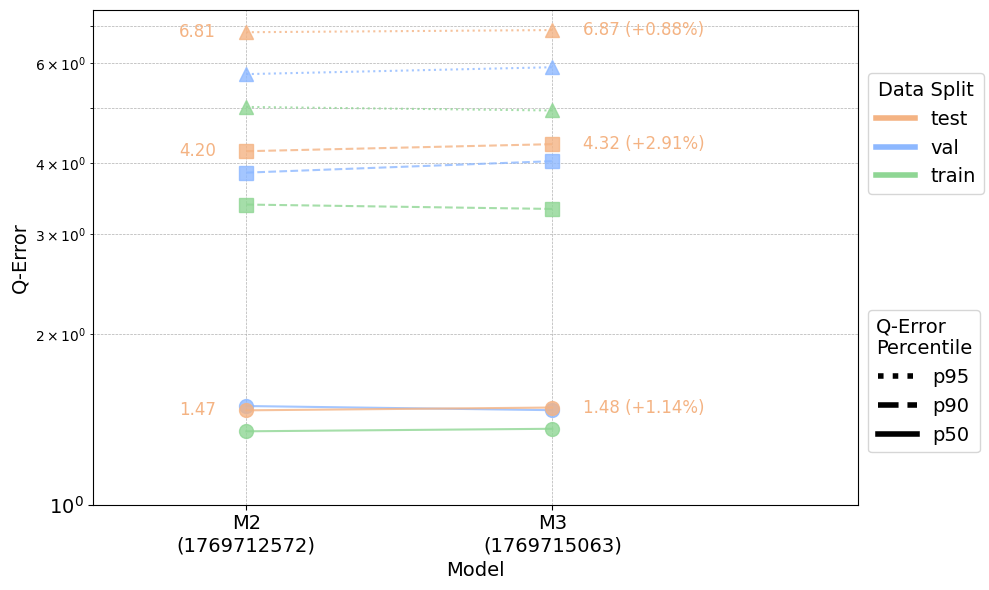

In [51]:
# Plot a Q-error comparison of M2 to M3 only for lower bound queries.
plot_qerror_comparison(
    results=results,
    model_mapping={
        'M2': MODEL_MAPPING['M2'],
        'M3': MODEL_MAPPING['M3'],
    },
    filename="model_comparison_qerror_plot_m2_m3.svg",
    initial="M2",
    final="M3",
)

In [56]:
# Create a version of results that only contains queries that are isolated, i.e., have only one concurrent query, 
# and one that contains queries that have multiple concurrent queries.
isolated_results = {
    short_model_name: {
        split: {
            "p50": 10.0,
            "p90": 10.0,
            "p95": 10.0,
        }
        for split in ["train", "val", "test"]
    }
    for short_model_name in MODEL_MAPPING.keys()
}   
non_isolated_results = {
    short_model_name: {
        split: {
            "p50": 10.0,
            "p90": 10.0,
            "p95": 10.0,
        }
        for split in ["train", "val", "test"]
    }
    for short_model_name in MODEL_MAPPING.keys()
}

for short_model_name, iconq_model_id in MODEL_MAPPING.items():

    if len(iconq_model_id) == 0:
        continue

    q_errors_isolated = {split: [] for split in ["train", "val", "test"]}
    q_errors_non_isolated = {split: [] for split in ["train", "val", "test"]}

    for split in ["train", "val", "test"]:
        for query_id, pred in pred_y[short_model_name][split].items():
            true, true_is_lower_bound, num_concurrent_queries = true_y[split][query_id]
            
            q_err = q_error(
                true=true,
                pred=pred,
                true_is_lower_bound=true_is_lower_bound,
            )
            if num_concurrent_queries == 1:
                q_errors_isolated[split].append(q_err)
            else:
                q_errors_non_isolated[split].append(q_err)

        isolated_results[short_model_name][split]["p50"] = np.percentile(q_errors_isolated[split], 50)
        isolated_results[short_model_name][split]["p90"] = np.percentile(q_errors_isolated[split], 90)
        isolated_results[short_model_name][split]["p95"] = np.percentile(q_errors_isolated[split], 95)

        non_isolated_results[short_model_name][split]["p50"] = np.percentile(q_errors_non_isolated[split], 50)
        non_isolated_results[short_model_name][split]["p90"] = np.percentile(q_errors_non_isolated[split], 90)
        non_isolated_results[short_model_name][split]["p95"] = np.percentile(q_errors_non_isolated[split], 95)



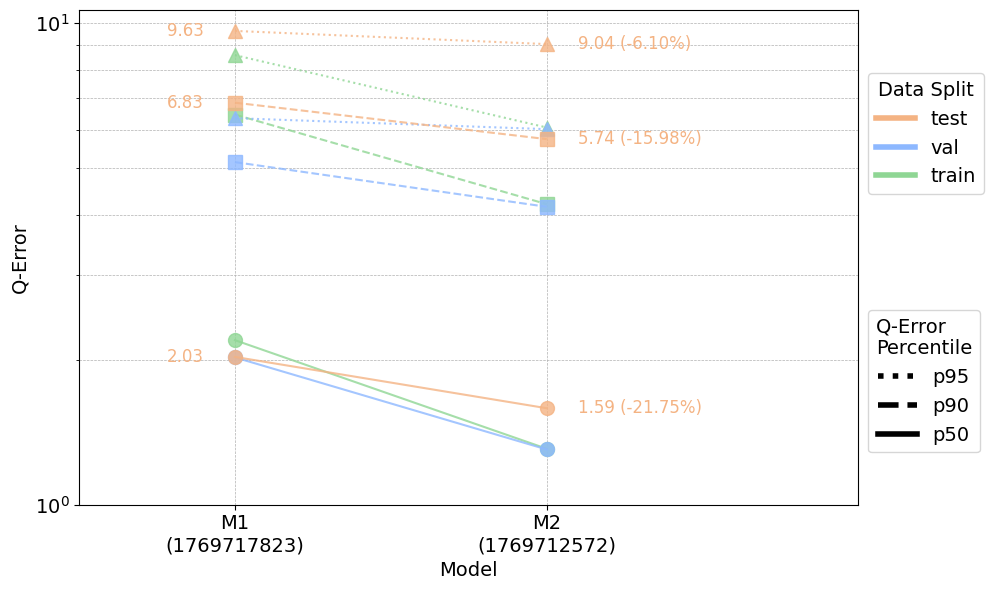

In [59]:
# Plot a Q-error comparison of M2 to M3 only for lower bound queries.
plot_qerror_comparison(
    results=isolated_results,
    model_mapping={
        'M1': MODEL_MAPPING['M1'],
        'M2': MODEL_MAPPING['M2'],
    },
    filename="model_comparison_qerror_plot_m1_m2_isolated.svg",
    initial="M1",
    final="M2",
)